## Open Exploration

*Kleine intro over wat er in dit bestand gebeurd*

In [1]:
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# make sure pandas is version 1.0 or higher
# make sure networkx is version 2.4 or higher
print(pd.__version__)
print(nx.__version__)

2.2.3
3.4.2


In [3]:
from ema_workbench import (Model, Policy, ema_logging, SequentialEvaluator, MultiprocessingEvaluator, perform_experiments, save_results, load_results)

from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time

In [4]:
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(2)

In [12]:
def get_do_nothing_dict():
    return {l.name:0 for l in dike_model.levers}

# Define 4 policies
policies = [
    # Do nothing
    Policy("Base case", **{l.name: 0 for l in dike_model.levers}),

    # Increase dike height with 5 dm every decision step
    Policy("Dikes only", **dict(get_do_nothing_dict(), **{
        'A.1_DikeIncrease 0': 5, 'A.1_DikeIncrease 1': 5, 'A.1_DikeIncrease 2': 5,
        'A.2_DikeIncrease 0': 5, 'A.2_DikeIncrease 1': 5, 'A.2_DikeIncrease 2': 5,
        'A.3_DikeIncrease 0': 5, 'A.3_DikeIncrease 1': 5, 'A.3_DikeIncrease 2': 5,
        'A.4_DikeIncrease 0': 5, 'A.4_DikeIncrease 1': 5, 'A.4_DikeIncrease 2': 5,
        'A.5_DikeIncrease 0': 5, 'A.5_DikeIncrease 1': 5, 'A.5_DikeIncrease 2': 5
    })),

    # Implement RfR on all locations at all decision steps
    Policy("RfR only", **dict(get_do_nothing_dict(), **{
        '0_RfR 0': 1, '0_RfR 1': 1, '0_RfR 2': 1,
        '1_RfR 0': 1, '1_RfR 1': 1, '1_RfR 2': 1,
        '2_RfR 0': 1, '2_RfR 1': 1, '2_RfR 2': 1,
        '3_RfR 0': 1, '3_RfR 1': 1, '3_RfR 2': 1,
        '4_RfR 0': 1, '4_RfR 1': 1, '4_RfR 2': 1,
        '5_RfR 0': 1, '5_RfR 1': 1, '5_RfR 2': 1,
        '6_RfR 0': 1, '6_RfR 1': 1, '6_RfR 2': 1
    })),

    #
     Policy("Final Policy", **dict(get_do_nothing_dict(),
                                      **{'0_RfR 0':1,
                                         '2_RfR 0':1,
                                         '3_RfR 0':1,
                                         'EWS_DaysToThreat': 3,
                                         'A.3_DikeIncrease 0':0.5,
                                          'A.4_DikeIncrease 0':0.5,
                                          'A.5_DikeIncrease 0':0.5,
    }))
]

In [13]:
n_scenarios = 100 # misschien aanpassen naar 500??

# running the model through EMA workbench
with MultiprocessingEvaluator(dike_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(n_scenarios, policies)

save_results((experiments, outcomes), "open_exploration.tar.gz")

[MainProcess/INFO] pool started with 18 workers
[MainProcess/INFO] performing 100 scenarios * 4 policies * 1 model(s) = 400 experiments
100%|████████████████████████████████████████| 400/400 [00:14<00:00, 27.06it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool
[MainProcess/INFO] results saved successfully to C:\Users\lmvan\PycharmProjects\EPA141A_Group12_2025\final assignment\open_exploration.tar.gz


[MainProcess/INFO] results loaded successfully from C:\Users\lmvan\PycharmProjects\EPA141A_Group12_2025\final assignment\open_exploration.tar.gz


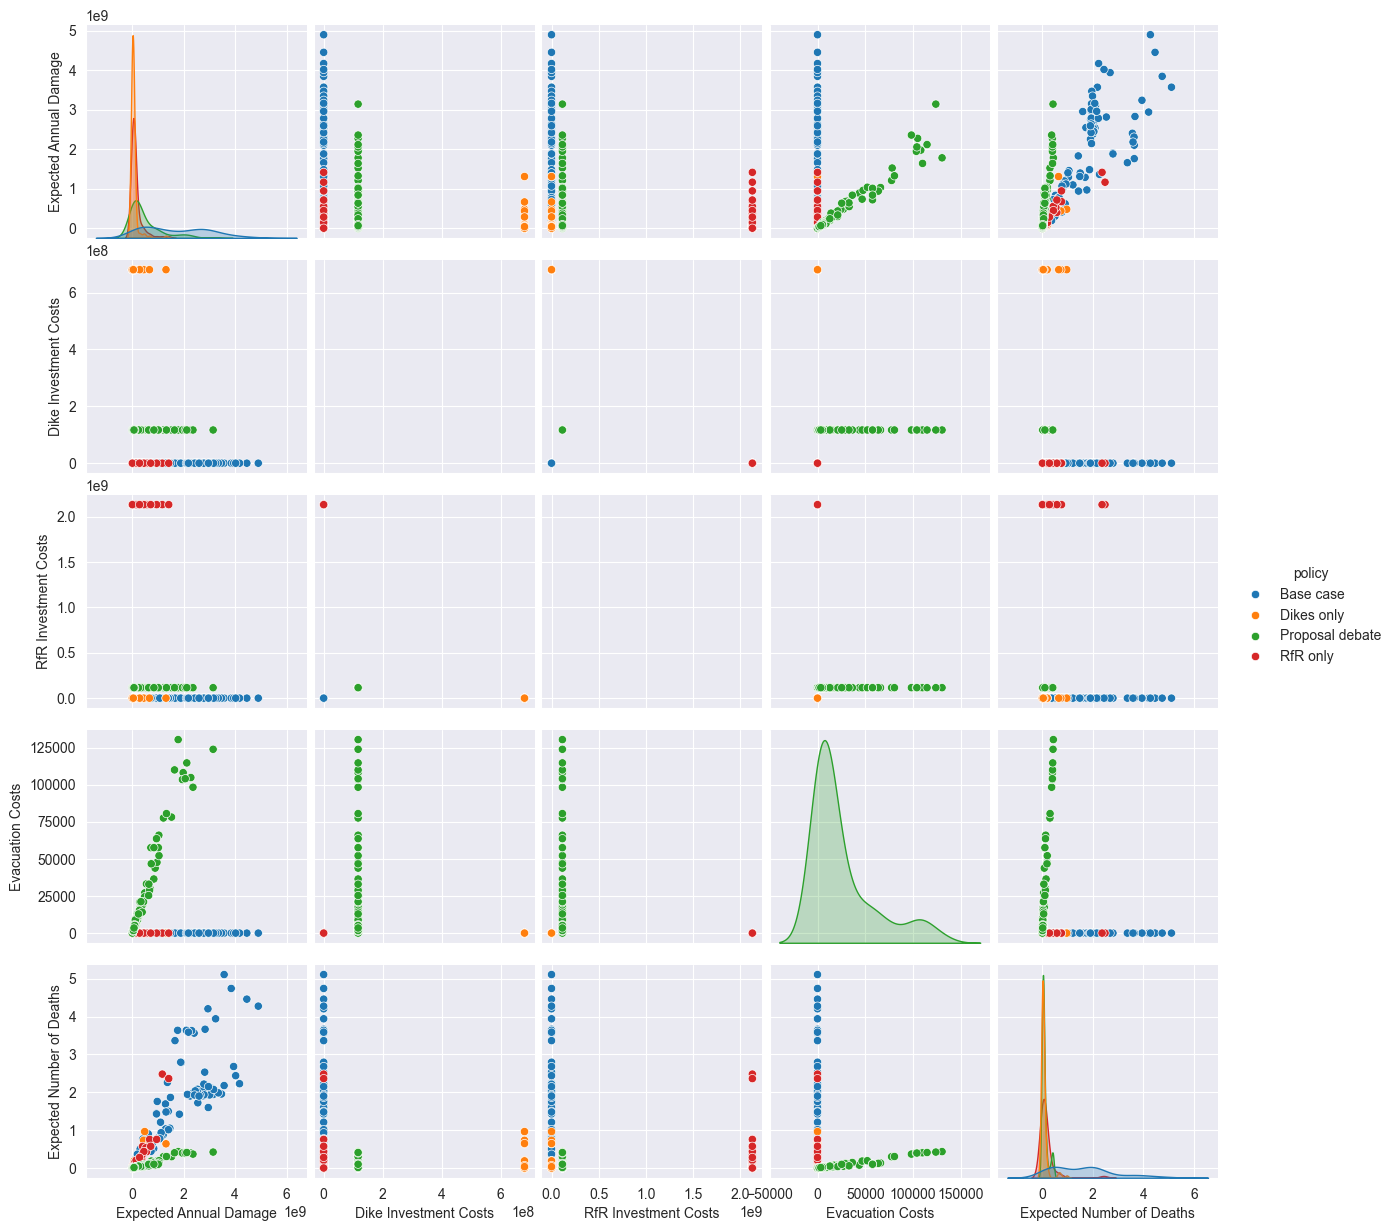

In [14]:
experiments, outcomes = load_results('open_exploration.tar.gz')

policies = experiments['policy']

data = pd.DataFrame.from_dict(outcomes)
data['policy'] = policies

plot = sns.pairplot(data, hue='policy', vars=outcomes.keys(), )
#plot.savefig("open_exp.png")
plt.show()

In [15]:
# CHAT code om de waarden van de uncertainties te vinden. Nog zorgen dat dit opgeslagen wordt, zodat het gebruikt kan worden in de scenario_MORDM.ipynb file

import pandas as pd
import numpy as np

uncertainties = [unc.name for unc in dike_model.uncertainties]

# Unpack results
experiments, outcomes = load_results('open_exploration.tar.gz')

# Convert 'Expected Number of Deaths' outcome into a DataFrame
deaths = pd.DataFrame(outcomes['Expected Number of Deaths'])

# Add scenario and policy info
deaths['scenario'] = experiments.index
deaths['policy'] = experiments['policy']

# Sum deaths across locations/years (if multi-dimensional)
deaths['total_deaths'] = deaths.drop(columns=['scenario', 'policy']).sum(axis=1)

# Find the scenarios with max and min deaths
max_idx = deaths['total_deaths'].idxmax()
min_idx = deaths['total_deaths'].idxmin()

# Get the corresponding experiment rows (lever values and uncertainties)
max_experiment = experiments.loc[max_idx]
min_experiment = experiments.loc[min_idx]

# Print results
print("⚠️ Highest number of deaths:")
print(f"Policy: {max_experiment['policy']}, Scenario index: {max_idx}")
print(f"Total deaths: {deaths.loc[max_idx]['total_deaths']}")
print("\nLever settings for highest death scenario:")
print(max_experiment[uncertainties])  # drop policy label for clarity

print("\n" + "-"*80 + "\n")

print("✅ Lowest number of deaths:")
print(f"Policy: {min_experiment['policy']}, Scenario index: {min_idx}")
print(f"Total deaths: {deaths.loc[min_idx]['total_deaths']}")
print("\nLever settings for lowest death scenario:")
print(min_experiment[uncertainties])

[MainProcess/INFO] results loaded successfully from C:\Users\lmvan\PycharmProjects\EPA141A_Group12_2025\final assignment\open_exploration.tar.gz


⚠️ Highest number of deaths:
Policy: Base case, Scenario index: 1
Total deaths: 5.109805873025817

Lever settings for highest death scenario:
discount rate 0                   3.5
discount rate 1                   4.5
discount rate 2                   4.5
A.0_ID flood wave shape            28
A.1_Bmax                   243.719488
A.1_pfail                    0.056824
A.1_Brate                        10.0
A.2_Bmax                   137.541909
A.2_pfail                    0.128396
A.2_Brate                        10.0
A.3_Bmax                   174.866856
A.3_pfail                    0.007062
A.3_Brate                         1.0
A.4_Bmax                   271.558027
A.4_pfail                    0.493569
A.4_Brate                        10.0
A.5_Bmax                    61.204006
A.5_pfail                    0.631425
A.5_Brate                         1.5
Name: 1, dtype: object

--------------------------------------------------------------------------------

✅ Lowest number of deaths:
Pol